## Data Loading and Standardization

### In order to ensure that clustering algorithms handle each feature equally, this phase loads the breast cancer dataset and standardizes all 30 numerical features.

In [15]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA


data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

## The K-Means Elbow Approach

### This section computes its Silhouette Score using K-Means with k=2 after estimating a suitable number of clusters using the Elbow Method.

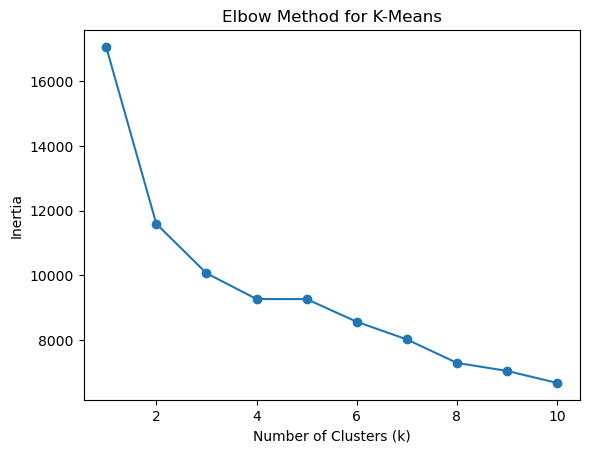

0.3447344346611054

In [16]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_silhouette

## DBSCAN Parameter Lookup

### In order to determine the DBSCAN configuration that generates significant clusters with the greatest Silhouette Score, this section tries several eps and min_samples values.

In [3]:
eps_values = [0.5, 0.7, 1.0, 1.2]
min_samples_values = [3, 5, 10]

best_score = -1
best_params = None

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)

        
        if len(set(labels)) <= 1:
            continue

        score = silhouette_score(X_scaled, labels)
        if score > best_score:
            best_score = score
            best_params = (eps, ms)

best_score, best_params

(-1, None)

## Variance Explained via PCA

### To find the number of main components required to preserve about 85% of the variation in the dataset, PCA is applied to the standardized data.

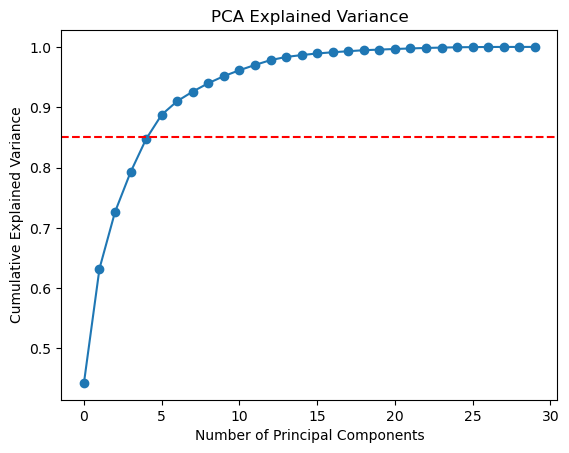

np.int64(6)

In [4]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.plot(cum_var, marker='o')
plt.axhline(0.85, color='red', linestyle='--')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

num_pcs = np.argmax(cum_var >= 0.85) + 1
num_pcs

## Top Features and PCA Loadings

### The top three characteristics that contribute most to PC1 are shown in a heatmap that displays PCA loadings.

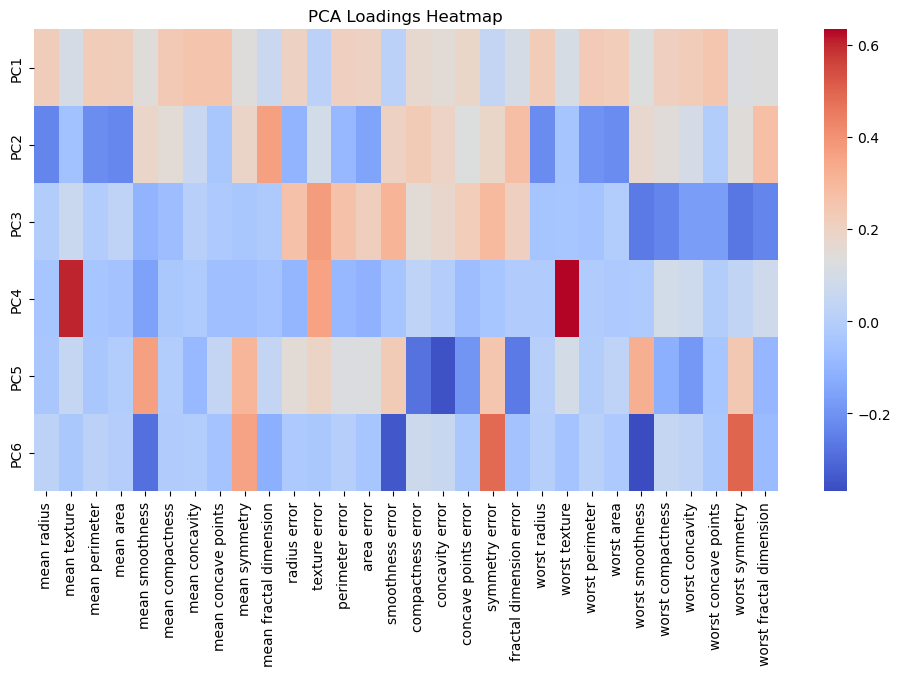

mean concave points     0.260854
mean concavity          0.258400
worst concave points    0.250886
Name: PC1, dtype: float64

In [5]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns,
    index=[f"PC{i+1}" for i in range(len(df.columns))]
)

plt.figure(figsize=(12, 6))
sns.heatmap(loadings.iloc[:num_pcs], cmap="coolwarm")
plt.title("PCA Loadings Heatmap")
plt.show()

top3_PC1 = loadings.loc["PC1"].abs().sort_values(ascending=False).head(3)
top3_PC1

## Dimensionality Diminishment

### After the PCA analysis, the dataset is reduced to the ideal number of primary components.

In [6]:
pca_final = PCA(n_components=num_pcs)
X_reduced = pca_final.fit_transform(X_scaled)

## K-Means on PCA Information

### To determine whether dimensionality reduction enhances clustering quality, K-Means is repeated on the PCA-reduced dataset.

In [17]:
kmeans_pca = KMeans(n_clusters=2, random_state=42)
kmeans_pca_labels = kmeans_pca.fit_predict(X_reduced)

kmeans_pca_silhouette = silhouette_score(X_reduced, kmeans_pca_labels)
kmeans_pca_silhouette

0.3774843043219229

## DBSCAN on PCA Information

### The PCA-reduced data is subjected to DBSCAN once more in order to assess its performance in comparison to the initial high-dimensional clustering.

In [8]:
best_score_pca = -1
best_params_pca = None

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_reduced)

        if len(set(labels)) <= 1:
            continue

        score = silhouette_score(X_reduced, labels)
        if score > best_score_pca:
            best_score_pca = score
            best_params_pca = (eps, ms)

best_score_pca, best_params_pca

(-0.18191999845798745, (1.2, 10))

## Visual Verification

### The two-dimensional separation of the PCA-based clusters is visually evaluated via a scatterplot of PC1 vs. PC2.

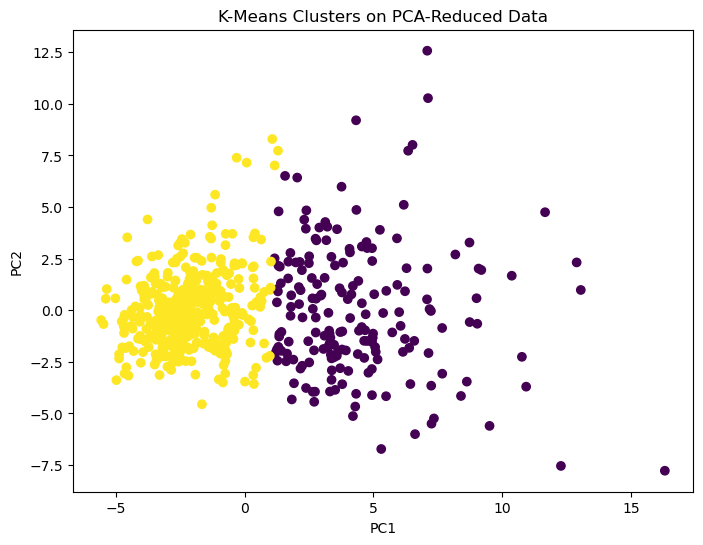

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=kmeans_pca_labels, cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters on PCA-Reduced Data")
plt.show()

##### Because the breast cancer dataset has strong, well-separated patterns and K-Means with k=2 frequently generates clusters that roughly correspond to benign vs. malignant cases even though the algorithm has no access to the true labels, the unsupervised K-Means clusters usually align very closely with the actual medical diagnosis.